Saving GraphiteExport.csv to GraphiteExport (2).csv
Optimal SARIMA Order: (0, 0, 0)
Optimal Seasonal Order: (0, 1, 1, 12)


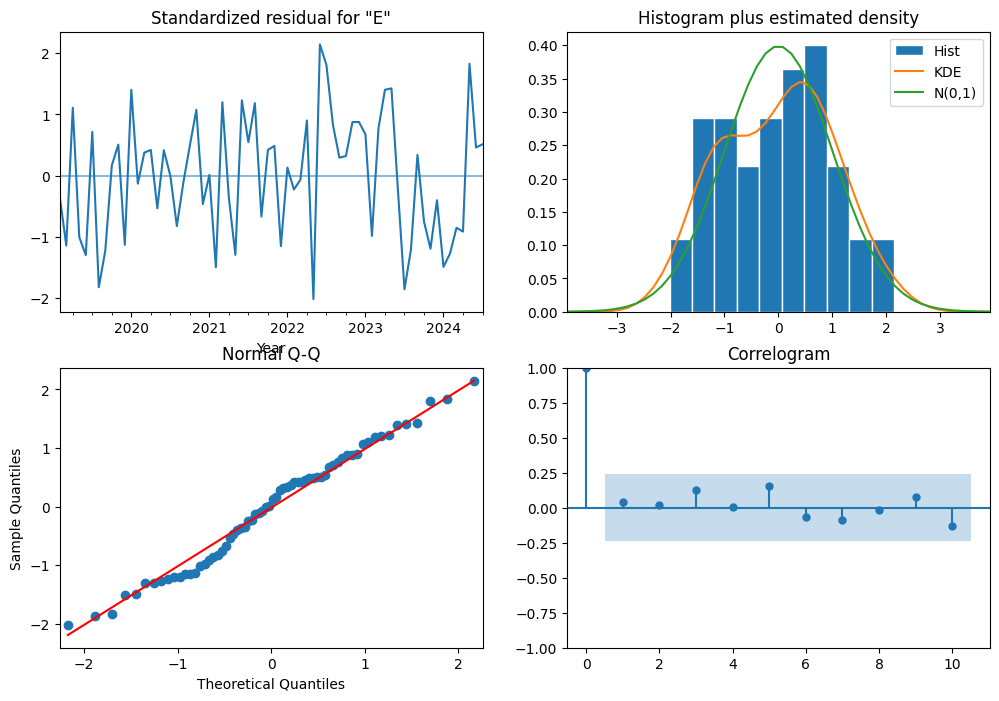


MAPE  : 46.04%
RMSE  : 191800.97


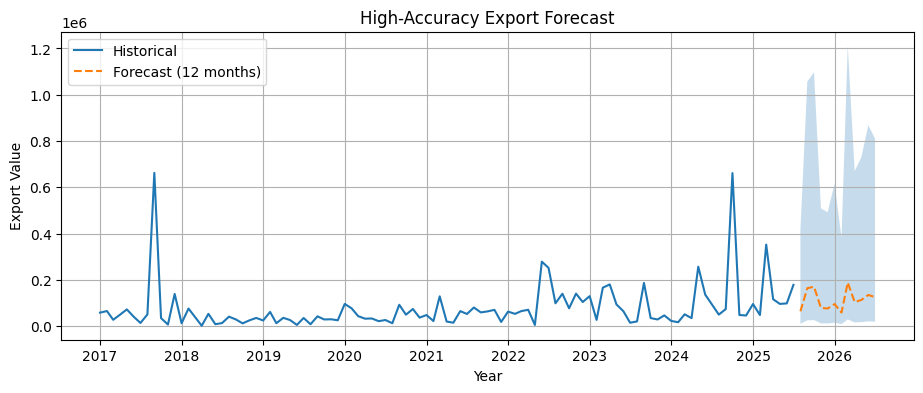


FINAL 12-MONTH FORECAST
                 Forecast      Lower CI      Upper CI
2025-08-01   64395.107423  10012.357891  4.141612e+05
2025-09-01  164299.105858  25545.752074  1.056700e+06
2025-10-01  170589.059178  26523.734196  1.097154e+06
2025-11-01   79116.685363  12301.316058  5.088439e+05
2025-12-01   76605.579885  11910.881322  4.926936e+05
2026-01-01   95737.701572  14885.604985  6.157430e+05
2026-02-01   59406.038147   9242.210962  3.818434e+05
2026-03-01  188541.098323  29332.651362  1.211883e+06
2026-04-01  104284.836396  16224.318069  6.703103e+05
2026-05-01  113686.982630  17687.075420  7.307443e+05
2026-06-01  135140.804783  21024.795902  8.686428e+05
2026-07-01  125999.721040  19602.653861  8.098868e+05


In [ ]:
# ===============================
# HIGH-ACCURACY SARIMAX PIPELINE
# ===============================

!pip install statsmodels pmdarima --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import pmdarima as pm

# -------------------------------
# 1. Upload & Load Data
# -------------------------------
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df['Year'] = pd.to_datetime(df['Year'], format='%Y-%m')
df.set_index('Year', inplace=True)
df = df.asfreq('MS')

# -------------------------------
# 2. Log Transform (CRITICAL)
# -------------------------------
df['Export_log'] = np.log(df['Export'])

# -------------------------------
# 3. Train-Test Split
# -------------------------------
train = df['Export_log'][:-12]
test  = df['Export_log'][-12:]

# -------------------------------
# 4. AUTO SARIMA (AIC + BIC OPTIMAL)
# -------------------------------
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=1,
    trace=False,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

order = auto_model.order
seasonal_order = auto_model.seasonal_order

print("Optimal SARIMA Order:", order)
print("Optimal Seasonal Order:", seasonal_order)

# -------------------------------
# 5. Fit Final SARIMAX (with trend)
# -------------------------------
model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# -------------------------------
# 6. Diagnostics (must look clean)
# -------------------------------
results.plot_diagnostics(figsize=(12,8))
plt.show()

# -------------------------------
# 7. Forecast on Test Set
# -------------------------------
forecast_log = results.get_forecast(steps=12)
pred_log = forecast_log.predicted_mean
conf_int_log = forecast_log.conf_int()

# Back-transform
pred = np.exp(pred_log)
test_actual = np.exp(test)

# -------------------------------
# 8. Accuracy Metrics
# -------------------------------
mape = mean_absolute_percentage_error(test_actual, pred)
rmse = np.sqrt(mean_squared_error(test_actual, pred))

print(f"\nMAPE  : {mape*100:.2f}%")
print(f"RMSE  : {rmse:.2f}")


# -------------------------------
# 9. Refit on FULL DATA for FINAL FORECAST
# -------------------------------
final_model = SARIMAX(
    df['Export_log'],
    order=order,
    seasonal_order=seasonal_order,
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(disp=False)

final_forecast_log = final_results.get_forecast(steps=12)
final_forecast = np.exp(final_forecast_log.predicted_mean)
final_ci = np.exp(final_forecast_log.conf_int())

# -------------------------------
# 10. Plot Final Forecast
# -------------------------------
plt.figure(figsize=(11,4))
plt.plot(df['Export'], label='Historical')
plt.plot(final_forecast, '--', label='Forecast (12 months)')
plt.fill_between(
    final_ci.index,
    final_ci.iloc[:,0],
    final_ci.iloc[:,1],
    alpha=0.25
)
plt.title("High-Accuracy Export Forecast")
plt.xlabel("Year")
plt.ylabel("Export Value")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# 11. Forecast Table
# -------------------------------
forecast_df = pd.DataFrame({
    "Forecast": final_forecast,
    "Lower CI": final_ci.iloc[:,0],
    "Upper CI": final_ci.iloc[:,1]
})

print("\nFINAL 12-MONTH FORECAST")
print(forecast_df)


Saving GraphiteExport.csv to GraphiteExport (3).csv
Train period: 2017-01-01 00:00:00 → 2024-07-01 00:00:00
Test period : 2024-08-01 00:00:00 → 2025-07-01 00:00:00
Selected order: (0, 0, 0)
Selected seasonal: (0, 1, 1, 12)

TEST SET ACCURACY
MAPE : 46.04%
RMSE : 191800.97


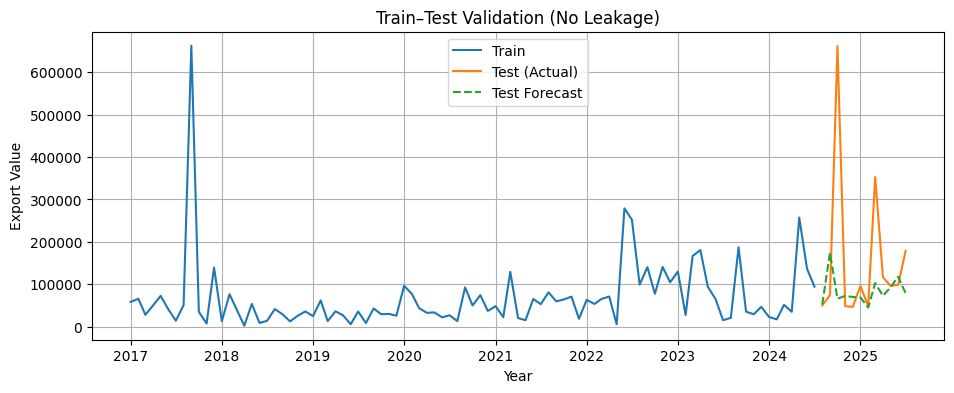

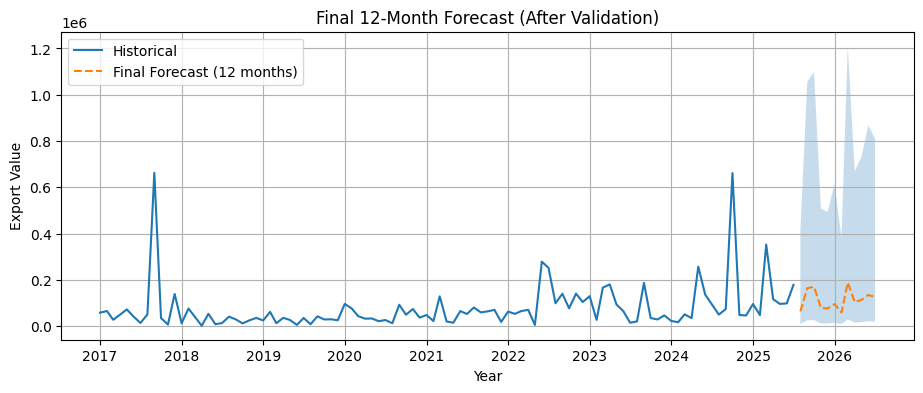


FINAL FORECAST TABLE
                 Forecast      Lower CI      Upper CI
2025-08-01   64395.107423  10012.357891  4.141612e+05
2025-09-01  164299.105858  25545.752074  1.056700e+06
2025-10-01  170589.059178  26523.734196  1.097154e+06
2025-11-01   79116.685363  12301.316058  5.088439e+05
2025-12-01   76605.579885  11910.881322  4.926936e+05
2026-01-01   95737.701572  14885.604985  6.157430e+05
2026-02-01   59406.038147   9242.210962  3.818434e+05
2026-03-01  188541.098323  29332.651362  1.211883e+06
2026-04-01  104284.836396  16224.318069  6.703103e+05
2026-05-01  113686.982630  17687.075420  7.307443e+05
2026-06-01  135140.804783  21024.795902  8.686428e+05
2026-07-01  125999.721040  19602.653861  8.098868e+05


In [ ]:
# ==========================================
# TIME-SERIES TRAIN / TEST / FINAL FORECAST
# ==========================================

!pip install statsmodels pmdarima --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
import pmdarima as pm

# ------------------------------------------
# 1. Upload & Load Data
# ------------------------------------------
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

df['Year'] = pd.to_datetime(df['Year'], format='%Y-%m')
df.set_index('Year', inplace=True)
df = df.asfreq('MS')

# ------------------------------------------
# 2. Log Transform (stabilizes variance)
# ------------------------------------------
df['Export_log'] = np.log(df['Export'])

# ------------------------------------------
# 3. Train-Test Split (last 12 months = test)
# ------------------------------------------
train = df['Export_log'][:-12]
test  = df['Export_log'][-12:]

print(f"Train period: {train.index[0]} → {train.index[-1]}")
print(f"Test period : {test.index[0]} → {test.index[-1]}")

# ------------------------------------------
# 4. Auto SARIMA on TRAIN ONLY
# ------------------------------------------
auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=1,
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    information_criterion="aic"
)

order = auto_model.order
seasonal_order = auto_model.seasonal_order

print("Selected order:", order)
print("Selected seasonal:", seasonal_order)

# ------------------------------------------
# 5. Fit SARIMAX on TRAIN
# ------------------------------------------
model = SARIMAX(
    train,
    order=order,
    seasonal_order=seasonal_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

# ------------------------------------------
# 6. Forecast TEST period
# ------------------------------------------
forecast_log = results.get_forecast(steps=12)
pred_log = forecast_log.predicted_mean

# Back-transform
pred = np.exp(pred_log)
actual = np.exp(test)

# ------------------------------------------
# 7. Accuracy Metrics (REAL PERFORMANCE)
# ------------------------------------------
mape = mean_absolute_percentage_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))

print(f"\nTEST SET ACCURACY")
print(f"MAPE : {mape*100:.2f}%")
print(f"RMSE : {rmse:.2f}")

# ------------------------------------------
# 8. Plot Train / Test / Prediction
# ------------------------------------------
plt.figure(figsize=(11,4))
plt.plot(np.exp(train), label="Train")
plt.plot(actual, label="Test (Actual)")
plt.plot(pred, '--', label="Test Forecast")
plt.title("Train–Test Validation (No Leakage)")
plt.xlabel("Year")
plt.ylabel("Export Value")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------
# 9. Refit on FULL DATA for FINAL FORECAST
# ------------------------------------------
final_model = SARIMAX(
    df['Export_log'],
    order=order,
    seasonal_order=seasonal_order,
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_results = final_model.fit(disp=False)

final_forecast_log = final_results.get_forecast(steps=12)
final_forecast = np.exp(final_forecast_log.predicted_mean)
final_ci = np.exp(final_forecast_log.conf_int())

# ------------------------------------------
# 10. Plot FINAL Forecast
# ------------------------------------------
plt.figure(figsize=(11,4))
plt.plot(df['Export'], label="Historical")
plt.plot(final_forecast, '--', label="Final Forecast (12 months)")
plt.fill_between(
    final_ci.index,
    final_ci.iloc[:,0],
    final_ci.iloc[:,1],
    alpha=0.25
)
plt.title("Final 12-Month Forecast (After Validation)")
plt.xlabel("Year")
plt.ylabel("Export Value")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------
# 11. Forecast Table
# ------------------------------------------
forecast_df = pd.DataFrame({
    "Forecast": final_forecast,
    "Lower CI": final_ci.iloc[:,0],
    "Upper CI": final_ci.iloc[:,1]
})

print("\nFINAL FORECAST TABLE")
print(forecast_df)
